In [1]:

import os
import tensorflow as tf
import tensorflow_datasets as tfds
import keras
from keras import layers
# from keras.preprocessing.image import ImageDataGenerator


2026-02-11 09:54:17.047208: I tensorflow/core/platform/cpu_feature_guard.cc:183] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

In [3]:
devices=tf.config.experimental.list_physical_devices()
devices

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'),
 PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [4]:
IMG_SIZE = 128   # or whatever you trained with
BATCH_SIZE=32
train_ds, val_ds = tfds.load(
    "citrus_leaves",
    split=["train[:80%]", "train[80%:]"],
    as_supervised=True,
    data_dir="/app/data/tfds"
)
len(train_ds)


2026-02-11 09:54:20.316075: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1636] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 14815 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:d8:00.0, compute capability: 6.0


475

In [5]:
ds_info = tfds.builder("citrus_leaves", data_dir="/app/data/tfds").info
class_names = ds_info.features["label"].names
print(class_names)

['Black spot', 'canker', 'greening', 'healthy']


In [6]:
def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32)          # convert uint8 → float32
    image = image / 255.0                   # normalize to [0,1]
    return image, label


In [7]:
train_ds_transformed = (
    train_ds
    .map(preprocess)
    .cache()
    .shuffle(1000)   # shuffle examples
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds_transformed = (
    val_ds
    .map(preprocess)
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)


In [8]:

from matplotlib import pyplot as plt


def visualize_dataset(dataset, num_images=9):
    plt.figure(figsize=(8, 8))
    count = 0
    dataset_iter = dataset.unbatch().as_numpy_iterator()
    for image, label in dataset_iter:
        if image.dtype != "float32":
            image = image.astype("float32") / 255.0

        plt.subplot(3, 3, count + 1)
        plt.imshow(image)
        plt.title(f"Label: {label}")
        plt.axis("off")
        count += 1
        if count >= num_images:
            break

    plt.show()


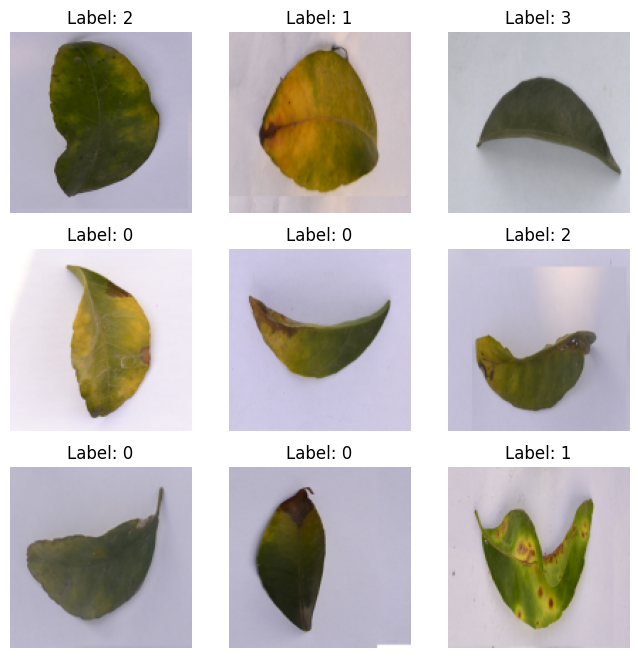

In [9]:

# Visualize
visualize_dataset(train_ds_transformed)



In [10]:
import keras

from keras import regularizers
reg = regularizers.l2(1e-4)

data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.2),
    keras.layers.RandomZoom(0.2),
    keras.layers.RandomContrast(0.2),
    keras.layers.RandomTranslation(0.1, 0.1),
])


In [11]:
model = keras.Sequential([
    keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    data_augmentation,

    keras.layers.Conv2D(32, 3, padding="same", activation="relu",
                        kernel_regularizer=reg),
    keras.layers.MaxPooling2D(),
    keras.layers.BatchNormalization(),

    keras.layers.Conv2D(64, 3, activation="relu",
                        kernel_regularizer=reg),
    keras.layers.Dropout(0.2),
    keras.layers.MaxPooling2D(),
    keras.layers.BatchNormalization(),

    keras.layers.Conv2D(128, 3, activation="relu",
                        kernel_regularizer=reg),
    keras.layers.Dropout(0.2),
    keras.layers.MaxPooling2D(),
    keras.layers.BatchNormalization(),

    keras.layers.GlobalAveragePooling2D(),

    keras.layers.Dense(64, activation="relu",
                       kernel_regularizer=reg),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(4, activation="softmax"),
])

In [12]:

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4), loss='sparse_categorical_crossentropy', metrics=['accuracy']
)


In [13]:
# model.summary()

In [14]:

class myCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if (logs.get('accuracy') > 0.95 and logs.get('val_accuracy') > 0.95):
            self.model.stop_training = True
            print("\n\nSufficient Metrics Reached!\n\n")


In [15]:
epochs=100
history=model.fit(
    train_ds_transformed,
    epochs=epochs,
    # batch_size=BATCH_SIZE,
    validation_data=val_ds_transformed,
    callbacks=myCallback()
    
)


Epoch 1/100


2026-02-11 09:54:24.566441: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:1014] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential_1/dropout/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2026-02-11 09:54:24.959207: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8905
2026-02-11 09:54:25.299673: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x76e86094e250 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-11 09:54:25.299722: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
2026-02-11 09:54:25.307843: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:255] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-11 09:54:25.499305: I ./tensorflow/compiler/jit/device_compiler.h:186] Comp

15/15 [==============================] - 6s 95ms/step - loss: 1.2251 - accuracy: 0.4716 - val_loss: 1.3961 - val_accuracy: 0.3697
Epoch 2/100
15/15 [==============================] - 1s 45ms/step - loss: 0.9401 - accuracy: 0.6442 - val_loss: 1.3917 - val_accuracy: 0.3697
Epoch 3/100
15/15 [==============================] - 0s 30ms/step - loss: 0.8350 - accuracy: 0.7137 - val_loss: 1.3950 - val_accuracy: 0.3697
Epoch 4/100
15/15 [==============================] - 0s 32ms/step - loss: 0.7443 - accuracy: 0.7179 - val_loss: 1.3987 - val_accuracy: 0.3697
Epoch 5/100
15/15 [==============================] - 0s 31ms/step - loss: 0.7052 - accuracy: 0.7558 - val_loss: 1.4038 - val_accuracy: 0.3697
Epoch 6/100
15/15 [==============================] - 0s 29ms/step - loss: 0.6341 - accuracy: 0.7747 - val_loss: 1.4140 - val_accuracy: 0.3697
Epoch 7/100
15/15 [==============================] - 0s 30ms/step - loss: 0.6061 - accuracy: 0.7768 - val_loss: 1.4311 - val_accuracy: 0.3697
Epoch 8/100
15/15 

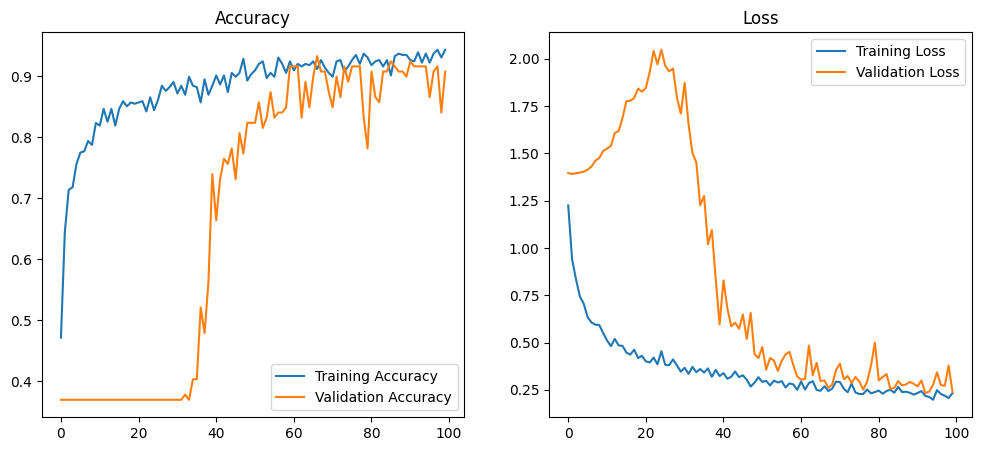

In [16]:
import matplotlib.pyplot as plt

acc      = history.history['accuracy']
val_acc  = history.history['val_accuracy']
loss     = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.legend(loc="lower right")
plt.title("Accuracy")

# Loss
plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.legend(loc="upper right")
plt.title("Loss")

plt.show()


In [17]:
# model.save("mymodel.h5")